Measuring a substraction circuit

In [39]:
from qiskit.circuit import (
    QuantumCircuit,
    QuantumRegister,
    AncillaRegister,
    ClassicalRegister,
)
from qiskit.circuit.library import CDKMRippleCarryAdder

In [40]:
num_state_qubits = 3
adder = CDKMRippleCarryAdder(num_state_qubits, kind='half')
 
subtrahend = QuantumRegister(num_state_qubits, 'A')
minuend = QuantumRegister(num_state_qubits + 1, 'M')
anc = AncillaRegister(adder.num_ancillas, 'anc')
difference = ClassicalRegister(num_state_qubits, 'diff')
 
qc = QuantumCircuit(subtrahend, minuend, anc, difference)
 
# Subtract 11 - 5
#the values start at 0
#each time you "load" a value, you change it it one
#for ex, 11 = 1011 or 2^3 + 2^1 + 2^0 = 8 + 2 + 1 = 11
#so we change the bits in the 0th, 1st, and 3rd position to 1 to represent 11
qc.x([minuend[0], minuend[1], minuend[3]])
#same goes for 5, 5 = 2^2 + 2^0 = 4 + 1 = 5
qc.x([subtrahend[0], subtrahend[2]])
 
qc.append(adder.inverse().to_gate(label=r'  $Adder^\dagger$  '), subtrahend[:] + minuend[:] + anc[:])
qc.measure(minuend[0:num_state_qubits], difference)

In [41]:
from qiskit_aer import Aer
from qiskit import transpile

backend = Aer.get_backend("aer_simulator")

qc = transpile(qc, backend)
qc.save_statevector() 

result = backend.run(qc, shots=1024).result()
counts = result.get_counts()
print(counts)

{'110': 1024}


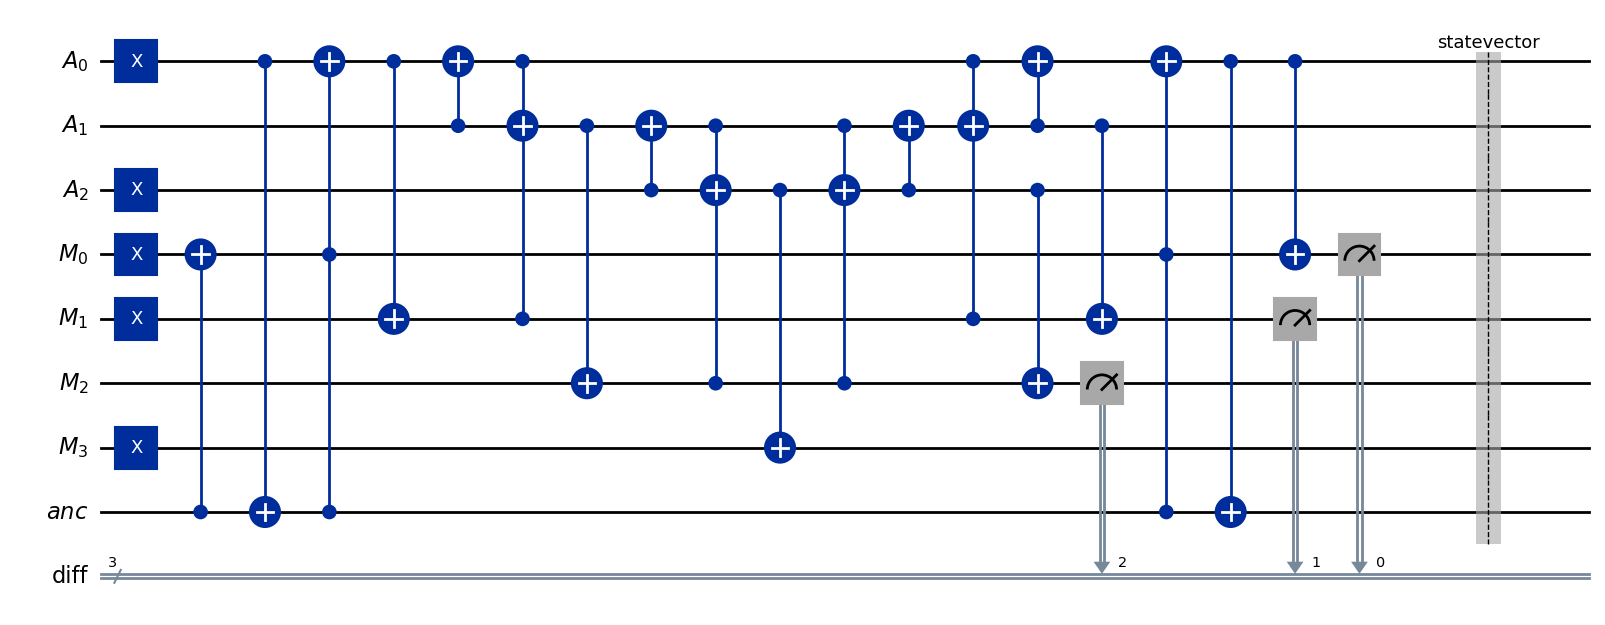

In [42]:
qc.draw("mpl")

In [43]:
from qiskit import QuantumCircuit

print("qubits:", qc.num_qubits)
print("depth:", qc.depth())
print("size:", qc.size())
print("ops:", qc.count_ops())

qubits: 8
depth: 19
size: 27
ops: OrderedDict({'cx': 13, 'ccx': 6, 'x': 5, 'measure': 3, 'save_statevector': 1})


In [44]:
from time import perf_counter
from statistics import mean, stdev

from qiskit import transpile
from qiskit_aer import AerSimulator


def time_transpile_and_run(
    qc,
    backend=None,
    shots=10_000,
    optimization_level=3,
    repeats=5,
    warmup=1,
):
    """
    Measures wall-clock time for:
      - transpile (compile) time
      - backend.run(...) + job.result() time

    Notes:
      - warmup runs help reduce one-time initialization/JIT effects (esp. Aer).
      - results are wall-clock on your machine (compile + simulation), not QPU gate-time.
    """
    backend = backend or AerSimulator()

    # --- Warmup (not counted) ---
    for _ in range(warmup):
        tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
        backend.run(tqc, shots=shots).result()

    # --- Timed repeats ---
    compile_times = []
    run_times = []
    total_times = []

    for _ in range(repeats):
        t0 = perf_counter()
        tqc = transpile(qc, backend=backend, optimization_level=optimization_level)
        t1 = perf_counter()
        job = backend.run(tqc, shots=shots)
        _ = job.result()
        t2 = perf_counter()

        compile_times.append(t1 - t0)
        run_times.append(t2 - t1)
        total_times.append(t2 - t0)

    def summarize(xs):
        return {
            "mean_s": mean(xs),
            "std_s": stdev(xs) if len(xs) > 1 else 0.0,
            "min_s": min(xs),
            "max_s": max(xs),
        }

    return {
        "compile": summarize(compile_times),
        "run": summarize(run_times),
        "total": summarize(total_times),
        "params": {
            "shots": shots,
            "optimization_level": optimization_level,
            "repeats": repeats,
            "warmup": warmup,
            "backend": type(backend).__name__,
        },
    }


# Example:
metrics = time_transpile_and_run(qc, shots=20_000, optimization_level=3, repeats=10, warmup=2)
print(metrics)

{'compile': {'mean_s': 0.17278177090120153, 'std_s': 0.018241057269403112, 'min_s': 0.15476650000346126, 'max_s': 0.20487512500403682}, 'run': {'mean_s': 0.22883061219836237, 'std_s': 0.046505503823097205, 'min_s': 0.16564520799875027, 'max_s': 0.3137236250040587}, 'total': {'mean_s': 0.4016123830995639, 'std_s': 0.060762285243200306, 'min_s': 0.3341426249971846, 'max_s': 0.508301959001983}, 'params': {'shots': 20000, 'optimization_level': 3, 'repeats': 10, 'warmup': 2, 'backend': 'AerSimulator'}}


Comparison cicuit

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

def _maj(qc, a, b, c):
    qc.cx(c, b); qc.cx(c, a); qc.ccx(a, b, c)

def _uma(qc, a, b, c):
    qc.ccx(a, b, c); qc.cx(c, a); qc.cx(a, b)

def cuccaro_adder_circuit(n: int) -> QuantumCircuit:
    a = QuantumRegister(n, "a")
    b = QuantumRegister(n, "b")
    cin = QuantumRegister(1, "cin")
    cout = QuantumRegister(1, "cout")
    qc = QuantumCircuit(a, b, cin, cout)

    _maj(qc, cin[0], b[0], a[0])
    for i in range(1, n):
        _maj(qc, a[i-1], b[i], a[i])

    qc.cx(a[n-1], cout[0])

    for i in reversed(range(1, n)):
        _uma(qc, a[i-1], b[i], a[i])
    _uma(qc, cin[0], b[0], a[0])
    return qc

def load_int_le(qc, reg, value: int):
    # little-endian: reg[0] is LSB
    for i in range(len(reg)):
        if (value >> i) & 1:
            qc.x(reg[i])

def bits_le_to_int(bitstr: str) -> int:
    # Qiskit prints bitstrings MSB->LSB, so reverse for LE integer
    return int(bitstr[::-1], 2)

def bin_n(value: int, n: int) -> str:
    return format(value, f"0{n}b")

# --- parameters ---
n = 4 #number of bits that a val can take
A_val, B_val = 15, 5

# --- registers / circuit ---
a = QuantumRegister(n, "a")
b = QuantumRegister(n, "b")
cin = QuantumRegister(1, "cin")
cout = QuantumRegister(1, "cout")
cb = ClassicalRegister(n, "sum")
cc = ClassicalRegister(1, "carry")

qc2 = QuantumCircuit(a, b, cin, cout, cb, cc)

# load inputs
load_int_le(qc2, a, A_val)
load_int_le(qc2, b, B_val)

# add
qc2.append(cuccaro_adder_circuit(n).to_gate(), a[:] + b[:] + cin[:] + cout[:])

# measure sum and carry
qc2.measure(b, cb)
qc2.measure(cout[0], cc[0])

# simulate
sim = AerSimulator()
tqc2 = transpile(qc2, sim, optimization_level=3)
result = sim.run(tqc2, shots=4096).result()
counts = result.get_counts()

# decode most likely outcome
bitstr = max(counts, key=counts.get)      # like "1 0000"
carry_str, sum_str = bitstr.split()
sum_int = bits_le_to_int(sum_str)
carry_int = int(carry_str, 2)
res_int = sum_int + (carry_int << n)

# print verification info
print("Inputs:")
print(f"  A = {A_val:2d}  (bin {bin_n(A_val, n)})")
print(f"  B = {B_val:2d}  (bin {bin_n(B_val, n)})")
print()
print("Expected (classical):")
expected = A_val + B_val
print(f"  A+B = {expected:2d} (bin {bin_n(expected, n+1)}  -> carry|sum = {bin_n(expected, n+1)[0]}|{bin_n(expected, n+1)[1:]})")
print()
print("Measured (most likely):")
print("  raw bitstring (carry sum):", bitstr)
print(f"  carry = {carry_int} , sum = {sum_int:2d} (sum bin {bin_n(sum_int, n)})")
print(f"  result = {res_int:2d} (bin {bin_n(res_int, n+1)})")
print()
print("Counts (top few):")
for k in sorted(counts, key=counts.get, reverse=True)[:5]:
    print(f"  {k}: {counts[k]}")

Inputs:
  A = 15  (bin 01111)
  B =  5  (bin 00101)

Expected (classical):
  A+B = 20 (bin 010100  -> carry|sum = 0|10100)

Measured (most likely):
  raw bitstring (carry sum): 0 10100
  carry = 0 , sum =  5 (sum bin 00101)
  result =  5 (bin 000101)

Counts (top few):
  0 10100: 4096


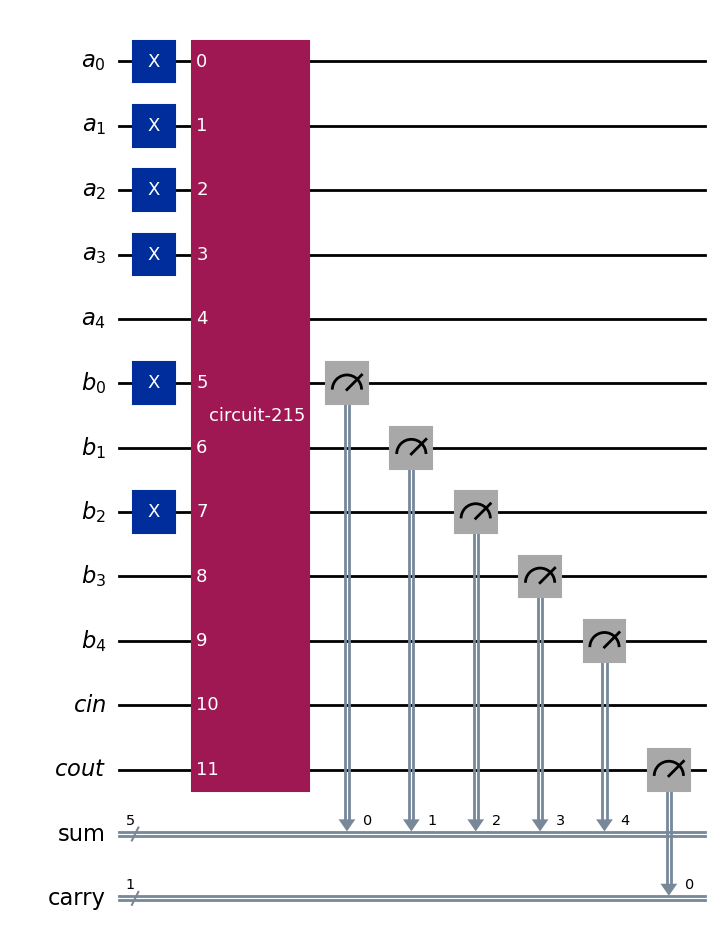

In [46]:
qc2.draw("mpl")

In [49]:
from qiskit import QuantumCircuit
print("Substraction")
print("qubits:", qc.num_qubits)
print("depth:", qc.depth())
print("size:", qc.size())
print("ops:", qc.count_ops())
metrics = time_transpile_and_run(qc, shots=20_000, optimization_level=3, repeats=10, warmup=2)
print("\n", metrics)

Substraction
qubits: 8
depth: 19
size: 27
ops: OrderedDict({'cx': 13, 'ccx': 6, 'x': 5, 'measure': 3, 'save_statevector': 1})

 {'compile': {'mean_s': 0.17420244989771164, 'std_s': 0.00770068458237481, 'min_s': 0.16041916699759895, 'max_s': 0.18383170799643267}, 'run': {'mean_s': 0.3083693750020757, 'std_s': 0.08328320779575257, 'min_s': 0.1979949580054381, 'max_s': 0.43733841700304765}, 'total': {'mean_s': 0.48257182489978734, 'std_s': 0.0867361773831551, 'min_s': 0.3726982500011218, 'max_s': 0.6169072499978938}, 'params': {'shots': 20000, 'optimization_level': 3, 'repeats': 10, 'warmup': 2, 'backend': 'AerSimulator'}}


In [50]:
from qiskit import QuantumCircuit
print("Addition")
print("qubits:", qc2.num_qubits)
print("depth:", qc2.depth())
print("size:", qc2.size())
print("ops:", qc2.count_ops())
metrics = time_transpile_and_run(qc2, shots=20_000, optimization_level=3, repeats=10, warmup=2)
print("\n", metrics)

Addition
qubits: 12
depth: 3
size: 13
ops: OrderedDict({'x': 6, 'measure': 6, 'circuit-215': 1})

 {'compile': {'mean_s': 0.16062605830084067, 'std_s': 0.018736938464079356, 'min_s': 0.14790858299966203, 'max_s': 0.2091284589987481}, 'run': {'mean_s': 0.03518391249817796, 'std_s': 0.004361407500086056, 'min_s': 0.031628374999854714, 'max_s': 0.04702433299826225}, 'total': {'mean_s': 0.19580997079901863, 'std_s': 0.022620441329715402, 'min_s': 0.18005983300099615, 'max_s': 0.25615279199701035}, 'params': {'shots': 20000, 'optimization_level': 3, 'repeats': 10, 'warmup': 2, 'backend': 'AerSimulator'}}
